# Buzz Lightyear Bitacora, fecha 4072

**02:** En esta notebook se busca maximizar la varianza entre las imagenes cortadas en cuadrantes.

**03:** Se entrena una red para cada cuadrante y al final se usa un clasificador RBF con las probabilidades de las 4 redes como entradas.  
`ul: 50, ur: 50, ll: 40, lr: 40; RBF: 45`

**04:** No se si la maximizacion de la varianza ayude o no, se pone a prueba en esta notebook, se hace cropping de los cuadrantes, sin aplicar color jittering. Le hice 100 epocas para asegurarme que no fuera por eso, resulta que empeoro el rendimiento. Supongo que el problema es el cropping.  
 `ul: 55, ur: 45, ll: 40, lr: 40; RBF: 45`

**06:** Tengo que volver a encontrar la forma de maximizar la varianza, pero ahora sin hacer cropping. Chat me dijo que buscara entre 0, 0.6, no lei la clase, pero lo hice asi.

**07:** Me di cuenta que el ColorJittering solo es random, en esta notebook lo quite e intente nuevas formas, salieron peores resultados. Tambien cambie la forma de hacer el meta-modelo, ahora se fija en los TPR de cada clase y los usa como pesos para entrenar el meta-modelo RBF. Me pone feliz que al que mejor le fue, es el que tiene color jittering.  
`ul: 45, ur: 40, ll: 50, lr: 40; RBF: 35`.

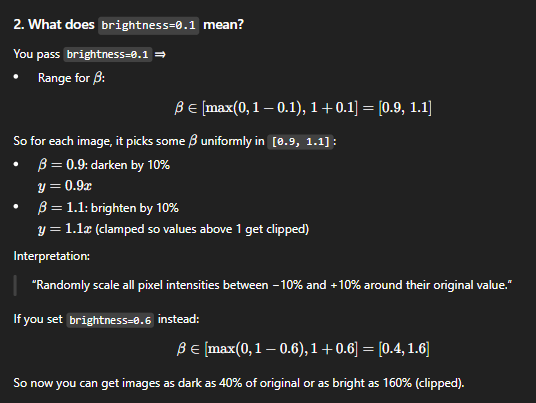

**08:** En esta notebook se vuelve a poner el ColorJittering, me pesaba no saber que hacia. No hice normalizacion, tome la imagen completa. Me doy cuenta que cuando haces los crops, el training llega a 100% muy rapido, pero generaliza mal; al tomar la imagen completa, tarda mas en llegar a 100% pero generaliza mejor. JAJAJAAJJ me da mucha risa que desde que le puse cuadrantes he estade pensando en la peli, Cuadrante Gamma del Sector 4!  
`ul: 55, ur: 55, ll: 45, lr: 45; RBF: 40`.   


**09:** Vale la pena normalizar? Mucho, si. Creo que sigo cargando desbalance de clases.  
`ul: 50, ur: 50, ll: 50, lr: 60; RBF: 40`

**10:** Un Pullock es igual si esta vertical u horizontal, tambien si tiene un flip. QUE?! PASO TODO LO CONTRARIO!

**11:** Se sobreajusta. Chat dijo que poner Conv2D y Pool2d ayudaria, tambien combio el optimizador, agrego `weight decay`, mientras voy a intentar con estos. 355 imagenes, 20 epocas.  
`ul: 63, ur: 50, ll: 55, lr:52, RBF: 44`

**12:** Agregue weight decay. Cambie la aleatoriedad del ColorJittering. Parece que lo mejor esta entre $0.0, 0.33$, son las que tuvieron mejor rendimiento.
Intente con las 355 imagenes y 40 epocas.  
`ul: 63, ur: 63, ll: 58, lr: 44; RBF: 38`

**13:** En 12, parecica que les faltaba entrenamiento, subi a 100 epocas. Parece que lo mejor es usar muy poco ColorJittering, se suaviza el entrenamiento y la validacion. Parece que no es buena ida hacer stacking con un RBF. 
`ul: 75, ur: 75, ll: 75, lr: 80; RBF: 45`

**14:** Cambie el optimizador a AdamW. Hice una arquitectura mas grande para las redes individuales. Creo que no es buena idea hacer stacking con un RBF. Imito las convolucionales con puras ReLU y Linear, creo muchisimas mas imagenes.

**15:** Intente con muchisimas epocas y no doy.

**16:** Intente imitar las convolucionales con puras ReLU y Linear, creo muchisimas mas imagenes. No doy.

**17:** Olvido entrenar muchos modelos y mejor solo hago uno muy bueno.

**18:** DeepPatchMLPNet con 20 epocas. Wow!
```
Epoch 20 | train_loss=0.4649, train_acc=0.749 | val_loss=1.4564, val_acc=0.596
Best val_acc (DeepPatchMLPNet): 0.723
```

**19:** DeepPatchMLPNet con 100 epocas. No se que hice que se sobreajusto tanto...
```
Epoch 100 | train_loss=0.0231, train_acc=0.990 | val_loss=2.0846, val_acc=0.596
Best val_acc (DeepPatchMLPNet): 0.660
```

**20:** Voy a volver a SmallConvFreeNet, pero con 100 epocas. No se sobreajusta.
```
Epoch 100 | train_loss=0.8048, train_acc=0.596 | val_loss=1.0212, val_acc=0.489
Best val_acc (SmallConvFreeNet): 0.617
```

**21:**
```
Epoch 100 | train_loss=0.6407, train_acc=0.706 | val_loss=0.8247, val_acc=0.638
Best val_acc (SmallConvFreeNet): 0.702
```

**22:** Y si entreno para categorizar los monos?
```
Epoch 100 | train_loss=1.4009, train_acc=0.483 | val_loss=1.5339, val_acc=0.447
Best val_acc (SmallConvFreeNet): 0.574
```
```
Acc: 0.6595744680851063
```

**23:** Voy a juntar todos los cuadrantes! gggg!!!!!! tiene que jalar!! wow! concatene 2 y hace magia, creo
```
Epoch 100 | train_loss=0.8136, train_acc=0.702 | val_loss=2.0014, val_acc=0.617
Best val_acc (SmallConvFreeNet): 0.702
```
```
Acc: 0.8085106382978723
```



# Loading the DataSet

In [1]:
# export env with conda correctly:
# conda env export --from-history > environment.yml

# to create env from file:
# conda env create -f environment.yml

In [2]:
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, WeightedRandomSampler
import torch, numpy as np

In [3]:
painter_to_genre = {
    "Joan": "Joan",
    "Salvador": "Salvador",
    "Rene": "Rene",
    "Pablo": "Pablo",
    "Jackson": "Jackson",
    "Rembrandt": "Rembrandt",
    "Caravaggio": "Caravaggio",
    "Camille": "Camille",
    "Alfred": "Alfred",
    "Claude": "Claude",
    "Vincent": "Vincent",  
}

genre_to_label = {
    "Joan": 0,
    "Salvador": 1,
    "Rene": 2,
    "Pablo": 3,
    "Jackson": 4,
    "Rembrandt": 5,
    "Caravaggio": 6,
    "Camille": 7,
    "Alfred": 8,
    "Claude": 9,
    "Vincent": 10,
}

In [4]:
from pathlib import Path
import pandas as pd

root = Path("08 Clasificacion de Movimientos Artisticos/data")

# recoge todos los .jpg (ajusta extensiones si hay .png, etc.)
paths = sorted(root.glob("*.jpg"))

rows = []
for p in paths:
    stem = p.stem  # 'Joan_Miro_001'
    # ejemplo simple: pintor = todo menos la parte final si es número
    painter = stem.split("_")[0]
    genre = painter_to_genre[painter]
    label = genre_to_label[genre]

    rows.append({
        "path": str(p),
        "painter": painter,
        "genre": genre,
        "label": label,
    })

df = pd.DataFrame(rows)

In [5]:
print(df['genre'].value_counts())
df.head()

genre
Claude        30
Pablo         30
Alfred        20
Salvador      20
Rembrandt     20
Joan          20
Jackson       15
Vincent       15
Camille       10
Caravaggio    10
Rene          10
Name: count, dtype: int64


,path,painter,genre,label
0,08 Clasificacion de Movimientos Artisticos\dat...,Alfred,Alfred,8
1,08 Clasificacion de Movimientos Artisticos\dat...,Alfred,Alfred,8
2,08 Clasificacion de Movimientos Artisticos\dat...,Alfred,Alfred,8
3,08 Clasificacion de Movimientos Artisticos\dat...,Alfred,Alfred,8
4,08 Clasificacion de Movimientos Artisticos\dat...,Alfred,Alfred,8


In [6]:
from PIL import Image
import os

# Create the data_augmented folder if it doesn't exist
augmented_dir = "08 Clasificacion de Movimientos Artisticos/data_augmented"
os.makedirs(augmented_dir, exist_ok=True)

# Rotate images of genre "Expresionismo abstracto" by 90 degrees and save new versions
for idx, row in df.iterrows():
    # Expresionismo abstracto
    if row['genre'] == 'Expresionismo abstracto':
        # Rotation
        img_path = row['path']
        img = Image.open(img_path).convert("RGB")
        rotated = img.rotate(90, expand=True)
        base, ext = os.path.splitext(os.path.basename(img_path))
        new_path = os.path.join(augmented_dir, f"{base}_rotated90{ext}")
        rotated.save(new_path)
        print(f"Saved rotated image to {new_path}")
        rotated = img.rotate(180)
        new_path = os.path.join(augmented_dir, f"{base}_rotated180{ext}")
        rotated.save(new_path)
        print(f"Saved rotated image to {new_path}")
        # Flip
        flipped = img.transpose(Image.Transpose.FLIP_LEFT_RIGHT)
        new_path_flip = os.path.join(augmented_dir, f"{base}_flipped{ext}")
        flipped.save(new_path_flip)
        print(f"Saved flipped image to {new_path_flip}")
        # Flip
        flipped = rotated.transpose(Image.Transpose.FLIP_LEFT_RIGHT)
        new_path_flip = os.path.join(augmented_dir, f"{base}_flipped{ext}")
        flipped.save(new_path_flip)
        print(f"Saved flipped image to {new_path_flip}")


# Rotate images of genre "Expresionismo abstracto" by 90 degrees and save new versions
for idx, row in df.iterrows():
    # Expresionismo abstracto
    if row['genre'] == 'Cubismo':
        # Rotation
        img_path = row['path']
        img = Image.open(img_path).convert("RGB")
        rotated = img.rotate(90, expand=True)
        base, ext = os.path.splitext(os.path.basename(img_path))
        new_path = os.path.join(augmented_dir, f"{base}_rotated90{ext}")
        rotated.save(new_path)
        print(f"Saved rotated image to {new_path}")
        # Flip
        flipped = img.transpose(Image.Transpose.FLIP_LEFT_RIGHT)
        new_path_flip = os.path.join(augmented_dir, f"{base}_flipped{ext}")
        flipped.save(new_path_flip)
        print(f"Saved flipped image to {new_path_flip}")


# Rotate images of genre "Expresionismo abstracto" by 90 degrees and save new versions
for idx, row in df.iterrows():
    # Expresionismo abstracto
    if row['genre'] == 'Barroco':
        # Rotation
        img_path = row['path']
        img = Image.open(img_path).convert("RGB")
        base, ext = os.path.splitext(os.path.basename(img_path))
        # Flip
        flipped = img.transpose(Image.Transpose.FLIP_LEFT_RIGHT)
        new_path_flip = os.path.join(augmented_dir, f"{base}_flipped{ext}")
        flipped.save(new_path_flip)
        print(f"Saved flipped image to {new_path_flip}")
        # rotation 180
        rotated = img.rotate(180)
        new_path = os.path.join(augmented_dir, f"{base}_rotated180{ext}")
        rotated.save(new_path)
        print(f"Saved rotated image to {new_path}")
        


for idx, row in df.iterrows():
    # Expresionismo abstracto
    if row['genre'] == 'Surrealismo':
        # Rotation
        img_path = row['path']
        img = Image.open(img_path).convert("RGB")
        rotated = img.rotate(180, expand=True)
        base, ext = os.path.splitext(os.path.basename(img_path))
        new_path = os.path.join(augmented_dir, f"{base}_rotated180{ext}")
        rotated.save(new_path)
        print(f"Saved rotated image to {new_path}")
        # Flip
        flipped = img.transpose(Image.Transpose.FLIP_LEFT_RIGHT)
        new_path_flip = os.path.join(augmented_dir, f"{base}_flipped{ext}")
        flipped.save(new_path_flip)
        print(f"Saved flipped image to {new_path_flip}")

In [7]:
from pathlib import Path
import pandas as pd

root2 = Path("08 Clasificacion de Movimientos Artisticos/data_augmented")

# recoge todos los .jpg (ajusta extensiones si hay .png, etc.)
paths = sorted(root2.glob("*.jpg"))

rows = []
for p in paths:
    stem = p.stem  # 'Joan_Miro_001'
    # ejemplo simple: pintor = todo menos la parte final si es número
    painter = stem.split("_")[0]
    genre = painter_to_genre[painter]
    label = genre_to_label[genre]

    rows.append({
        "path": str(p),
        "painter": painter,
        "genre": genre,
        "label": label,
    })

df2 = pd.DataFrame(rows)

In [8]:
# concatena los dos dataframes
df = pd.concat([df, df2], ignore_index=True)
print(df['genre'].value_counts())
df.head()

genre
Pablo         90
Jackson       60
Joan          60
Salvador      60
Rembrandt     60
Caravaggio    30
Claude        30
Rene          30
Alfred        20
Vincent       15
Camille       10
Name: count, dtype: int64


,path,painter,genre,label
0,08 Clasificacion de Movimientos Artisticos\dat...,Alfred,Alfred,8
1,08 Clasificacion de Movimientos Artisticos\dat...,Alfred,Alfred,8
2,08 Clasificacion de Movimientos Artisticos\dat...,Alfred,Alfred,8
3,08 Clasificacion de Movimientos Artisticos\dat...,Alfred,Alfred,8
4,08 Clasificacion de Movimientos Artisticos\dat...,Alfred,Alfred,8


In [9]:
from torch.utils.data import Dataset
from PIL import Image

class PaintingDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["path"]).convert("RGB")
        y = int(row["label"])
        if self.transform is not None:
            img = self.transform(img)
        return img, y


# Data Engineering 😜

## maximize variance

In [10]:
import torch
from PIL import Image

def compute_mean_std_from_df(df, transform):
    channel_sum = torch.zeros(3)
    channel_sq_sum = torch.zeros(3)
    n_pixels = 0

    for path in df["path"]:
        img = Image.open(path).convert("RGB")
        x = transform(img)           # C×H×W, in [0,1]

        B, C, H, W = 1, *x.shape     # fake batch size 1
        n = B * H * W

        channel_sum    += x.view(C, -1).sum(dim=1)
        channel_sq_sum += (x**2).view(C, -1).sum(dim=1)
        n_pixels       += n

    mean = channel_sum / n_pixels
    var  = channel_sq_sum / n_pixels - mean ** 2
    std  = torch.sqrt(var + 1e-8)
    return mean, std

In [11]:
cul = 0.0
sul = 0.0
bul = 0.0
hul = 0.0

cur = .11
sur = .11
bur = .11
hur = .11

cll = .22
sll = .22
bll = .22
hll = .22

lrr = 0.33
slr = 0.33
blr = 0.33  
hlr = 0.33

In [12]:
from torchvision import transforms

transf_ul = transforms.Compose([
    # QuadrantCrop("ul"),
    transforms.Resize((128, 128)),
    transforms.ColorJitter(contrast=cul, saturation=sul, brightness=bul, hue=hul),
    transforms.ToTensor(),
    # get the mean and std for normalization
    # transforms.Normalize(mean=means.tolist(), std=stds.tolist()),
])


transf_ur = transforms.Compose([
    # QuadrantCrop("ur"),
    transforms.Resize((128, 128)),
    # transforms.RandomHorizontalFlip(p=1),
    transforms.ColorJitter(contrast=cur, saturation=sur, brightness=bur, hue=hur),
    transforms.ToTensor(),
    # transforms.Normalize(mean=means.tolist(), std=stds.tolist()),
])


transf_ll = transforms.Compose([
    # QuadrantCrop("ll"),
    transforms.Resize((128, 128)),
    transforms.ColorJitter(contrast=cll, saturation=sll, brightness=bll, hue=hll),
    transforms.ToTensor(),
    # transforms.Normalize(mean=means.tolist(), std=stds.tolist()),
])


transf_lr = transforms.Compose([
    # QuadrantCrop("lr"),
    transforms.Resize((128, 128)),
    transforms.ColorJitter(contrast=lrr, saturation=slr, brightness=blr, hue=hlr),
    transforms.ToTensor(),
    # transforms.Normalize(mean=means.tolist(), std=stds.tolist()),
])

# stat_ul, stat_ur, stat_ll, stat_lr defined as before (QuadrantCrop + Resize + ToTensor)
mean_ul, std_ul = compute_mean_std_from_df(df, transf_ul)
mean_ur, std_ur = compute_mean_std_from_df(df, transf_ur)
mean_ll, std_ll = compute_mean_std_from_df(df, transf_ll)
mean_lr, std_lr = compute_mean_std_from_df(df, transf_lr)

print("UL:", mean_ul, std_ul)
print("UR:", mean_ur, std_ur)
print("LL:", mean_ll, std_ll)
print("LR:", mean_lr, std_lr)


transf_ul = transforms.Compose([
    # QuadrantCrop("ul"),
    transforms.Resize((128, 128)),
    transforms.ColorJitter(contrast=cul, saturation=sul, brightness=bul, hue=hul),
    transforms.ToTensor(),
    # get the mean and std for normalization
    transforms.Normalize(mean=mean_ul.tolist(), std=std_ul.tolist()),
])

transf_ur = transforms.Compose([
    # QuadrantCrop("ur"),
    transforms.Resize((128, 128)),
    # transforms.RandomHorizontalFlip(p=1),
    transforms.ColorJitter(contrast=cur, saturation=sur, brightness=bur, hue=hur),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean_ur.tolist(), std=std_ur.tolist()),
])

transf_ll = transforms.Compose([
    # QuadrantCrop("ll"),
    transforms.Resize((128, 128)),
    transforms.ColorJitter(contrast=cll, saturation=sll, brightness=bll, hue=hll),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean_ll.tolist(), std=std_ll.tolist()),
])

transf_lr = transforms.Compose([
    # QuadrantCrop("lr"),
    transforms.Resize((128, 128)),
    transforms.ColorJitter(contrast=lrr, saturation=slr, brightness=blr, hue=hlr),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean_lr.tolist(), std=std_lr.tolist()),
])

UL: tensor([0.4856, 0.4244, 0.3618]) tensor([0.2590, 0.2491, 0.2405])
UR: tensor([0.4768, 0.4203, 0.3610]) tensor([0.2576, 0.2578, 0.2415])
LL: tensor([0.4588, 0.4187, 0.3742]) tensor([0.2572, 0.2641, 0.2466])
LR: tensor([0.4450, 0.4138, 0.3895]) tensor([0.2660, 0.2686, 0.2585])


# Transfarmation and split train and validation sets

In [13]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(df, test_size=0.1, stratify=df['label'], random_state=863)

In [14]:
train_df

,path,painter,genre,label
97,08 Clasificacion de Movimientos Artisticos\dat...,Joan,Joan,0
171,08 Clasificacion de Movimientos Artisticos\dat...,Salvador,Salvador,1
101,08 Clasificacion de Movimientos Artisticos\dat...,Joan,Joan,0
107,08 Clasificacion de Movimientos Artisticos\dat...,Pablo,Pablo,3
440,08 Clasificacion de Movimientos Artisticos\dat...,Salvador,Salvador,1
...,...,...,...,...
421,08 Clasificacion de Movimientos Artisticos\dat...,Rene,Rene,2
147,08 Clasificacion de Movimientos Artisticos\dat...,Rembrandt,Rembrandt,5
44,08 Clasificacion de Movimientos Artisticos\dat...,Claude,Claude,9
312,08 Clasificacion de Movimientos Artisticos\dat...,Pablo,Pablo,3


In [15]:
train_ul = PaintingDataset(train_df, transform=transf_ul)
train_ur = PaintingDataset(train_df, transform=transf_ur)
train_ll = PaintingDataset(train_df, transform=transf_ll)
train_lr = PaintingDataset(train_df, transform=transf_lr)

val_ul = PaintingDataset(val_df, transform=transf_ul)
val_ur = PaintingDataset(val_df, transform=transf_ur)
val_ll = PaintingDataset(val_df, transform=transf_ll)
val_lr = PaintingDataset(val_df, transform=transf_lr)

In [16]:
import torch.utils.data
train_ds = torch.utils.data.ConcatDataset([train_ul, train_ur])
val_ds = torch.utils.data.ConcatDataset([val_ul])

# Visualización de imágenes con los mejores parámetros encontrados

Label: 6 Caravaggio


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.3905787..1.9256268].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4091754..1.4980913].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4177687..2.2013109].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.3193133..2.1826074].


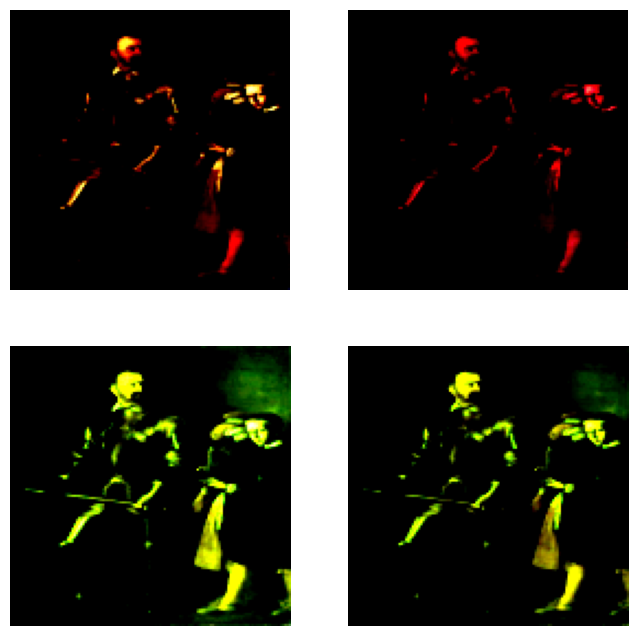

In [17]:
import random
r = random.randint(0, len(train_ul)-1)

img_ul, y = train_ul[r]
img_ur, y = train_ur[r]
img_ll, y = train_ll[r]
img_lr, y = train_lr[r]

print("Label:", y, train_df.iloc[r]["genre"])


import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(8, 8))

axes[0,0].imshow((img_ul).permute(1,2,0).cpu().numpy())
axes[0,0].axis("off")

axes[0,1].imshow((img_ur).permute(1,2,0).cpu().numpy())
axes[0,1].axis("off")

axes[1,0].imshow((img_ll).permute(1,2,0).cpu().numpy())
axes[1,0].axis("off")

axes[1,1].imshow((img_lr).permute(1,2,0).cpu().numpy())
axes[1,1].axis("off")

plt.show()


# ReLU

In [18]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if device.type == "cuda":
    print("GPU name:", torch.cuda.get_device_name(0))


Using device: cuda
GPU name: NVIDIA GeForce RTX 4060 Laptop GPU


In [19]:
import numpy as np
import torch

NUM_CLASSES = len(genre_to_label)

# labels must be integers 0..C-1 (you already have that)
labels_train = train_df["label"].values  # shape (N_train,)

# counts per class, ordered by label index
class_counts = np.bincount(labels_train, minlength=NUM_CLASSES).astype(float)
print("class_counts:", class_counts)

# inverse-frequency weights (rarer classes get higher weight)
class_weights = 1.0 / class_counts
# optional: normalize so average weight ~1
class_weights = class_weights * (NUM_CLASSES / class_weights.sum())
print("class_weights:", class_weights)

class_weights_t = torch.tensor(class_weights, dtype=torch.float32).to(device)


class_counts: [54. 54. 27. 81. 54. 54. 27.  9. 18. 27. 13.]
class_weights: [0.46178687 0.46178687 0.92357374 0.30785791 0.46178687 0.46178687
 0.92357374 2.77072121 1.3853606  0.92357374 1.9181916 ]


In [20]:
import torch.nn as nn

NUM_CLASSES = len(genre_to_label)

import torch.nn as nn

NUM_CLASSES = len(genre_to_label)

class SmallCNN(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        # Input: (B, 3, 128, 128) -> Flatten to (B, 3*128*128) = (B, 49152)
        self.flatten = nn.Flatten()
        
        # Fully connected layers to "imitate" conv + pooling + features via linear transforms and ReLUs
        # Using multiple linear layers with ReLUs to approximate hierarchical feature extraction
        self.features = nn.Sequential(
            nn.Linear(3 * 128 * 128, 1024),  # First "feature" layer (like conv)
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            
            nn.Linear(1024, 512),  # Second "feature" layer
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            
            nn.Linear(512, 256),  # Third "feature" layer
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            
            nn.Linear(256, 128),  # Final "feature" layer (like adaptive pooling to 128)
            nn.ReLU(inplace=True),
        )
        
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(128, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        x = self.flatten(x)  # Flatten input
        x = self.features(x)  # Fully connected "features" with ReLUs
        x = self.classifier(x)
        return x


In [21]:
import torch
import torch.nn as nn
import torch.nn.functional as F

NUM_CLASSES = len(genre_to_label)


class ConvFreeBlock(nn.Module):
    """
    Conv2d(in_channels, out_channels, kernel_size=3, padding=1, stride=1)
    implemented as: Unfold + Linear + ReLU.
    """
    def __init__(self, in_channels, out_channels, kernel_size=3, padding=1):
        super().__init__()
        self.kernel_size = kernel_size
        self.padding = padding
        self.unfold = nn.Unfold(kernel_size=kernel_size,
                                padding=padding,
                                stride=1)
        self.fc = nn.Linear(in_channels * kernel_size * kernel_size,
                            out_channels)

    def forward(self, x):
        # x: (B, C_in, H, W)
        B, C_in, H, W = x.shape

        # (B, C_in * k * k, H * W)
        patches = self.unfold(x)

        # (B, H * W, C_in * k * k)
        patches = patches.transpose(1, 2)

        # merge batch and spatial dims: (B * H * W, C_in * k * k)
        patches = patches.reshape(-1, patches.shape[-1])

        # apply Linear: (B * H * W, C_out)
        out = self.fc(patches)

        # ReLU activation
        out = F.relu(out, inplace=True)

        # reshape back to (B, H * W, C_out)
        out = out.reshape(B, H * W, -1)

        # (B, C_out, H, W)
        out = out.transpose(1, 2).reshape(B, -1, H, W)
        return out


def max_pool_2x2_with_relu(x):
    """
    2x2 max pooling using only linear ops + ReLU.
    x: (B, C, H, W) with H,W even.
    returns: (B, C, H/2, W/2)
    """
    B, C, H, W = x.shape
    assert H % 2 == 0 and W % 2 == 0, "H and W must be divisible by 2."

    # reshape into 2x2 patches
    # (B, C, H/2, 2, W/2, 2)
    x = x.reshape(B, C, H // 2, 2, W // 2, 2)

    # bring pooling-dim forward: (B, C, 2, 2, H/2, W/2)
    x = x.permute(0, 1, 3, 5, 2, 4)

    # flatten pooling dimension: (B, C, 4, H/2, W/2)
    x = x.reshape(B, C, 4, H // 2, W // 2)

    v0 = x[:, :, 0]  # (B, C, H/2, W/2)
    v1 = x[:, :, 1]
    v2 = x[:, :, 2]
    v3 = x[:, :, 3]

    def max2(a, b):
        # max(a,b) = 0.5 * (a + b + |a-b|)
        # |a-b| = ReLU(a-b) + ReLU(b-a)
        diff1 = a - b
        diff2 = b - a
        abs_diff = F.relu(diff1) + F.relu(diff2)
        return 0.5 * (a + b + abs_diff)

    m01 = max2(v0, v1)
    m23 = max2(v2, v3)
    m = max2(m01, m23)  # (B, C, H/2, W/2)
    return m


class SmallConvFreeNet(nn.Module):
    """
    Replica of your SmallCNN, but using only:
    - Linear layers
    - ReLU
    - Pooling expressed via Linear + ReLU
    """
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        # Input: (B, 3, 128, 128)
        self.block1 = ConvFreeBlock(3, 32, kernel_size=3, padding=1)
        self.block2 = ConvFreeBlock(32, 64, kernel_size=3, padding=1)
        self.block3 = ConvFreeBlock(64, 128, kernel_size=3, padding=1)

        self.dropout1 = nn.Dropout(p=0.5)
        self.fc1 = nn.Linear(128, 64)
        self.dropout2 = nn.Dropout(p=0.5)
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        # (B, 3, 128, 128)
        x = self.block1(x)              # -> (B, 32, 128, 128)
        x = max_pool_2x2_with_relu(x)   # -> (B, 32, 64, 64)

        x = self.block2(x)              # -> (B, 64, 64, 64)
        x = max_pool_2x2_with_relu(x)   # -> (B, 64, 32, 32)

        x = self.block3(x)              # -> (B, 128, 32, 32)
        x = max_pool_2x2_with_relu(x)   # -> (B, 128, 16, 16)

        # global average pooling: (B, 128, 1, 1) -> (B, 128)
        x = x.mean(dim=(2, 3))

        x = self.dropout1(x)
        x = F.relu(self.fc1(x), inplace=True)
        x = self.dropout2(x)
        logits = self.fc2(x)
        return logits

    def predict_proba(self, x):
        """Optional: apply Softmax to get probabilities."""
        logits = self.forward(x)
        return F.softmax(logits, dim=1)


In [22]:
import torch
import torch.nn as nn
import torch.nn.functional as F

NUM_CLASSES = len(genre_to_label)


class PatchEmbedding(nn.Module):
    """
    Split image into non-overlapping patches and embed each patch.
    Uses only Unfold + Linear + ReLU (later).
    """
    def __init__(self, image_size=128, patch_size=16, in_channels=3, embed_dim=256):
        super().__init__()
        assert image_size % patch_size == 0, "image_size must be divisible by patch_size"
        self.image_size = image_size
        self.patch_size = patch_size
        self.in_channels = in_channels
        self.embed_dim = embed_dim

        self.num_patches = (image_size // patch_size) ** 2
        self.unfold = nn.Unfold(kernel_size=patch_size, stride=patch_size)

        patch_dim = in_channels * patch_size * patch_size  # e.g. 3 * 16 * 16 = 768
        self.proj = nn.Linear(patch_dim, embed_dim)

        # learned positional embeddings (1, N, D)
        self.pos_embed = nn.Parameter(torch.zeros(1, self.num_patches, embed_dim))

    def forward(self, x):
        # x: (B, C, H, W) = (B, 3, 128, 128)
        B, C, H, W = x.shape
        assert H == self.image_size and W == self.image_size

        # (B, C*patch_size*patch_size, N_patches)
        patches = self.unfold(x)
        # (B, N_patches, patch_dim)
        patches = patches.transpose(1, 2)

        # embed each patch: (B, N_patches, embed_dim)
        tokens = self.proj(patches)
        tokens = tokens + self.pos_embed  # broadcast over batch
        return tokens  # (B, N, D)


class MLPMixerBlock(nn.Module):
    """
    One Mixer block:
    - token mixing: mixes across patches
    - channel mixing: mixes across channels
    Uses only Linear + ReLU and residual connections.
    """
    def __init__(self, num_patches, embed_dim,
                 token_mlp_dim=128, channel_mlp_dim=512):
        super().__init__()

        # token mixing
        self.token_mlp = nn.Sequential(
            nn.Linear(num_patches, token_mlp_dim),
            nn.ReLU(inplace=True),
            nn.Linear(token_mlp_dim, num_patches),
        )

        # channel mixing
        self.channel_mlp = nn.Sequential(
            nn.Linear(embed_dim, channel_mlp_dim),
            nn.ReLU(inplace=True),
            nn.Linear(channel_mlp_dim, embed_dim),
        )

    def forward(self, x):
        # x: (B, N, D)
        B, N, D = x.shape

        # ----- token mixing -----
        # work as (B, D, N)
        y = x.transpose(1, 2)              # (B, D, N)
        y = self.token_mlp(y)              # (B, D, N)
        y = y.transpose(1, 2)              # (B, N, D)
        x = x + y                          # residual

        # ----- channel mixing -----
        z = self.channel_mlp(x)            # (B, N, D)
        x = x + z                          # residual
        return x


class DeepPatchMLPNet(nn.Module):
    """
    Deep, non-convolutional, patch-based network.
    Uses:
      - PatchEmbedding (Unfold + Linear)
      - Several MLPMixerBlocks
      - Global average pooling over patches
      - Classifier Linear
    All nonlinearities are ReLU; Softmax can be applied externally if needed.
    """
    def __init__(
        self,
        num_classes=NUM_CLASSES,
        image_size=128,
        patch_size=16,
        embed_dim=256,
        num_blocks=6,
        token_mlp_dim=128,
        channel_mlp_dim=512,
        dropout_p=0.5,
    ):
        super().__init__()
        self.patch_embed = PatchEmbedding(
            image_size=image_size,
            patch_size=patch_size,
            in_channels=3,
            embed_dim=embed_dim,
        )

        num_patches = self.patch_embed.num_patches

        self.blocks = nn.ModuleList([
            MLPMixerBlock(
                num_patches=num_patches,
                embed_dim=embed_dim,
                token_mlp_dim=token_mlp_dim,
                channel_mlp_dim=channel_mlp_dim,
            )
            for _ in range(num_blocks)
        ])

        self.dropout = nn.Dropout(p=dropout_p)
        self.classifier = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        # x: (B, 3, 128, 128)
        x = self.patch_embed(x)  # (B, N, D)
        for blk in self.blocks:
            x = blk(x)            # (B, N, D)

        # global average over patches: (B, D)
        x = x.mean(dim=1)

        x = self.dropout(x)
        logits = self.classifier(x)  # (B, num_classes)
        return logits

    def predict_proba(self, x):
        """Optional helper: return class probabilities (Softmax)."""
        logits = self.forward(x)
        return F.softmax(logits, dim=1)


In [23]:
# Training loop for a single model
from torch.utils.data import DataLoader
from torch.optim import Adam
from tqdm import tqdm
from torch.optim import AdamW
from tqdm import tqdm

# assumes you already defined:
# class SmallConvFreeNet(nn.Module): ...
# and a global `device`

def train_one_model(
    train_loader,
    val_loader,
    num_epochs: int = 10,
    lr: float = 1e-3,
    class_weights: torch.Tensor | None = None,
    model_cls=SmallConvFreeNet,  # <- default to conv-free model
):
    # instantiate the chosen model (conv-free by default)
    model = model_cls().to(device)

    # handle optional class weights on the correct device
    if class_weights is not None:
        class_weights = class_weights.to(device)
        criterion = nn.CrossEntropyLoss(weight=class_weights)
    else:
        criterion = nn.CrossEntropyLoss()

    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    best_val_acc = 0.0
    best_state   = None
    history = {
        "train_loss": [],
        "train_acc":  [],
        "val_loss":   [],
        "val_acc":    [],
    }

    for epoch in range(num_epochs):
        # ---------- training ----------
        model.train()
        running_loss = 0.0
        total = 0
        correct = 0

        for imgs, labels in tqdm(
            train_loader,
            desc=f"Epoch {epoch+1}/{num_epochs}",
            leave=False
        ):
            imgs   = imgs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad()
            logits = model(imgs)

            # weighted CE if class_weights is not None
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * imgs.size(0)
            _, preds = logits.max(1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

        train_loss = running_loss / total
        train_acc  = correct / total

        # ---------- validation ----------
        model.eval()
        val_loss = 0.0
        val_total = 0
        val_correct = 0

        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs   = imgs.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)

                logits = model(imgs)
                loss = criterion(logits, labels)  # same criterion (weighted or not)

                val_loss    += loss.item() * imgs.size(0)
                _, preds    = logits.max(1)
                val_total   += labels.size(0)
                val_correct += (preds == labels).sum().item()

        val_loss /= val_total
        val_acc   = val_correct / val_total

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch+1:02d} | "
            f"train_loss={train_loss:.4f}, train_acc={train_acc:.3f} | "
            f"val_loss={val_loss:.4f}, val_acc={val_acc:.3f}"
        )

        # track best validation accuracy
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state   = model.state_dict()

    # restore best model (early-stopping style)
    if best_state is not None:
        model.load_state_dict(best_state)

    print(f"Best val_acc ({model_cls.__name__}): {best_val_acc:.3f}")
    return model, history


In [24]:
model = DeepPatchMLPNet(
    num_classes=NUM_CLASSES,
    image_size=128,
    patch_size=16,
    embed_dim=512,
    num_blocks=8,
    token_mlp_dim=256,
    channel_mlp_dim=1024,
    dropout_p=0.5,
)


In [25]:
# Train one model per quadrant
BATCH_SIZE = 32

# concat train_ul and train_ur datasets
train_ds = torch.utils.data.ConcatDataset([train_ul, train_ur, train_ll, train_lr])

train_ld_q = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
)
val_ld_q = DataLoader(
    val_ur,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

# Example: train the DeepPatchMLPNet instead of SmallConvFreeNet
model_deep, history_deep = train_one_model(
    train_ld_q,
    val_ld_q,
    num_epochs=100,
    lr=3e-3,
    class_weights=class_weights_t,   # or None
    model_cls=SmallConvFreeNet
)


Epoch 01 | train_loss=2.3115, train_acc=0.171 | val_loss=2.1445, val_acc=0.213


Epoch 02 | train_loss=2.1565, train_acc=0.231 | val_loss=2.0326, val_acc=0.277


Epoch 03 | train_loss=2.1005, train_acc=0.250 | val_loss=1.9633, val_acc=0.362


Epoch 04 | train_loss=2.0173, train_acc=0.315 | val_loss=1.9264, val_acc=0.340


Epoch 05 | train_loss=1.9372, train_acc=0.334 | val_loss=1.8276, val_acc=0.404


...

Epoch 96 | train_loss=0.9251, train_acc=0.696 | val_loss=1.0909, val_acc=0.660


Epoch 97 | train_loss=0.8806, train_acc=0.694 | val_loss=1.1652, val_acc=0.638


Epoch 98 | train_loss=0.8797, train_acc=0.708 | val_loss=1.2786, val_acc=0.617


Epoch 99 | train_loss=0.8046, train_acc=0.714 | val_loss=1.4511, val_acc=0.660


Epoch 100 | train_loss=0.8307, train_acc=0.693 | val_loss=1.3993, val_acc=0.660
Best val_acc (SmallConvFreeNet): 0.745


# Visualización del modelo

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
from scripts import style
style.mpl_apply()


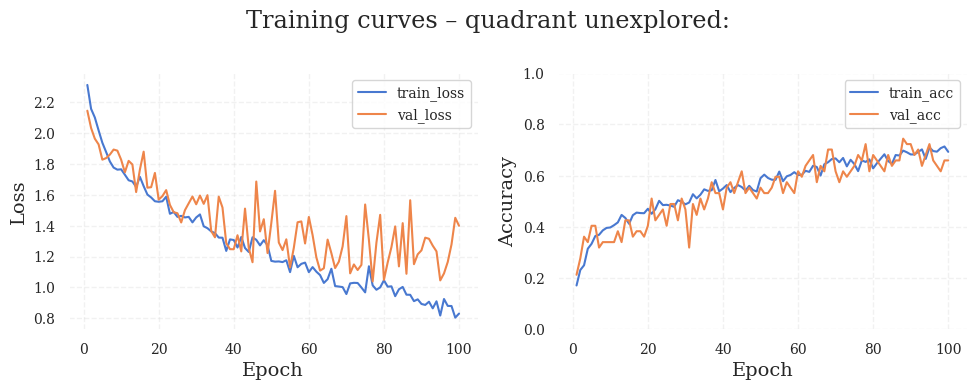

In [27]:

import matplotlib.pyplot as plt

hist_q = history_deep  # replace with hist_q from training above


epochs = range(1, len(hist_q["train_loss"]) + 1)

plt.figure(figsize=(10, 4))
plt.suptitle(f"Training curves – quadrant unexplored:")

# --- Loss ---
plt.subplot(1, 2, 1)
plt.plot(epochs, hist_q["train_loss"], label="train_loss")
plt.plot(epochs, hist_q["val_loss"],   label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)

# --- Accuracy ---
if "train_acc" in hist_q:
    plt.subplot(1, 2, 2)
    plt.plot(epochs, hist_q["train_acc"], label="train_acc")
    plt.plot(epochs, hist_q["val_acc"],   label="val_acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.ylim(0.0, 1.0)
    plt.legend()
    plt.grid(True, alpha=0.3)
else:
    # fallback if you didn't re-train with train_acc stored
    plt.subplot(1, 2, 2)
    plt.plot(epochs, hist["val_acc"], label="val_acc")
    plt.xlabel("Epoch")
    plt.ylabel("Val accuracy")
    plt.ylim(0.0, 1.0)
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [28]:
from PIL import Image
import torch
import numpy as np
import matplotlib.pyplot as plt

inv_genre = {v: k for k, v in genre_to_label.items()}
quadrant_name = "ul"  # fixed to ul since only one model

def show_quadrant_probs(img_path, model, transform):
    img = Image.open(img_path).convert("RGB")

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    fig.suptitle(f"Quadrant Analysis for {img_path.split('/')[-1]}")

    q = quadrant_name
    # apply transform for this quadrant (includes crop + resize + normalize)
    x_q = transform(img)        # C x H x W
    x_vis = x_q.clone()

    # for visualization: un-normalize using that quadrant's mean/std if you want
    # but simplest: just use raw (might look slightly off colors)
    x_vis = x_vis.permute(1, 2, 0).numpy()
    x_vis = np.clip(x_vis, 0, 1)

    # Image in left
    axes[0].imshow(x_vis)
    axes[0].axis("off")
    axes[0].set_title(f"Quadrant view: {q}")

    # model prediction
    model.eval()

    with torch.no_grad():
        x_batch = x_q.unsqueeze(0).to(device)
        logits = model(x_batch)
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]  # shape (C,)

    # Bar plot in right
    axes[1].bar(range(len(probs)), probs)
    axes[1].set_xticks(range(len(probs)))
    axes[1].set_xticklabels([inv_genre[j] for j in range(len(probs))], rotation=45, ha="right")
    axes[1].set_ylim(0, 1)
    axes[1].set_title(f"Probabilities for quadrant {q}")

    plt.tight_layout()
    plt.show()


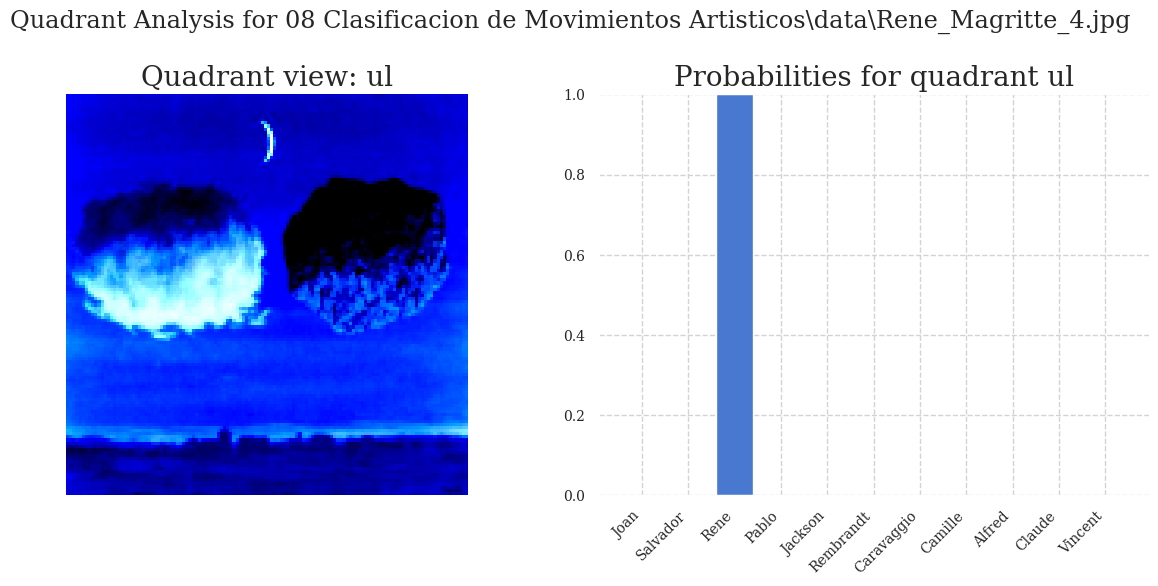

In [29]:
import random   
test_img = random.choice(train_df['path'].tolist())
show_quadrant_probs(test_img, model_deep, transf_ul)

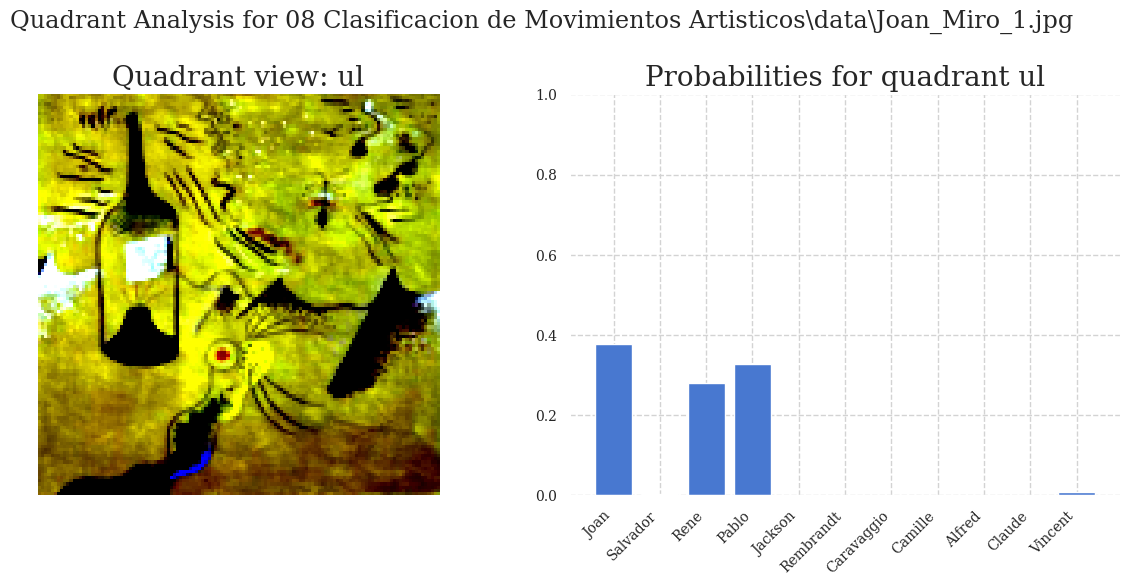

In [30]:
import random   
test_img = random.choice(val_df['path'].tolist())
show_quadrant_probs(test_img, model_deep, transf_ul)

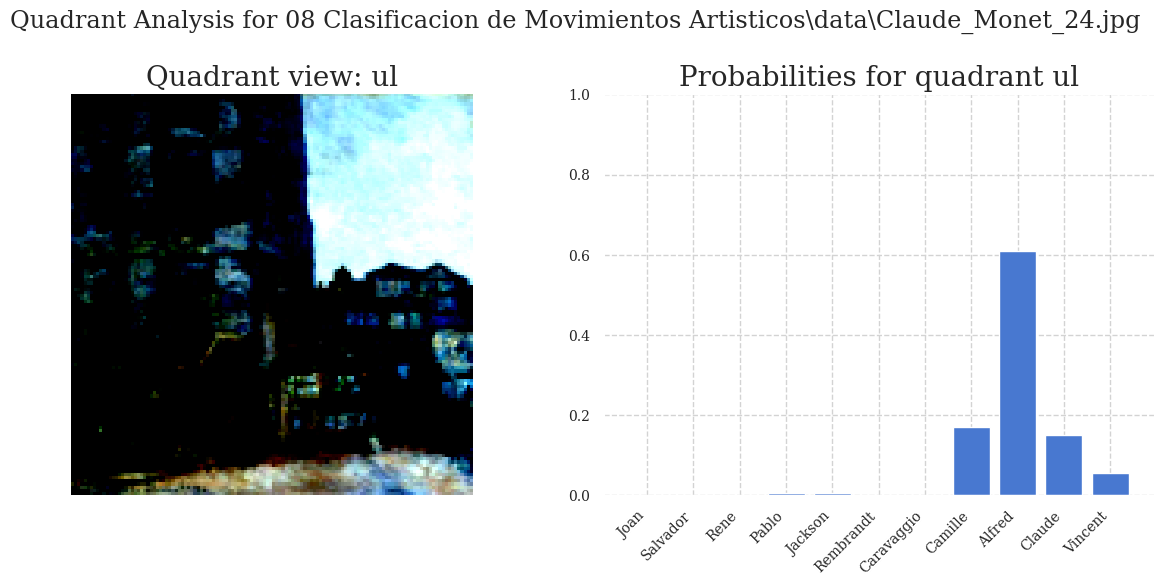

In [31]:
import random   
test_img = random.choice(val_df['path'].tolist())
show_quadrant_probs(test_img, model_deep, transf_ul)

In [32]:
ds = val_ul  # change for each quadrant: val_ul, val_ur, val_ll, val_lr
loader = DataLoader(
    ds,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

all_preds = []
all_labels = []

model_q = model_deep.to(device)
model_q.eval()

with torch.no_grad():
    for imgs, labels in loader:
        imgs   = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        logits = model_q(imgs)
        _, preds = logits.max(1)

        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

y_true = np.concatenate(all_labels)
y_pred = np.concatenate(all_preds)

# import confusion_matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true, y_pred, labels=np.arange(NUM_CLASSES))
# TPR_c = CM[c,c] / sum_j CM[c,j]
denom = cm.sum(axis=1).clip(min=1)  # avoid division by zero
tpr = cm.diagonal() / denom

print("Confusion matrix:\n", cm)
print("TPR:", tpr)


Confusion matrix:
 [[4 0 0 2 0 0 0 0 0 0 0]
 [0 6 0 0 0 0 0 0 0 0 0]
 [1 0 2 0 0 0 0 0 0 0 0]
 [1 0 1 6 0 0 0 0 0 0 1]
 [0 0 0 0 6 0 0 0 0 0 0]
 [0 0 0 0 0 5 1 0 0 0 0]
 [0 0 0 0 0 0 3 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 1]
 [0 0 0 0 0 0 0 0 0 2 0]
 [0 0 1 0 0 0 0 0 1 1 0]
 [0 0 0 0 0 0 0 0 0 2 0]]
TPR: [0.66666667 1.         0.66666667 0.66666667 1.         0.83333333
 1.         0.         0.         0.33333333 0.        ]


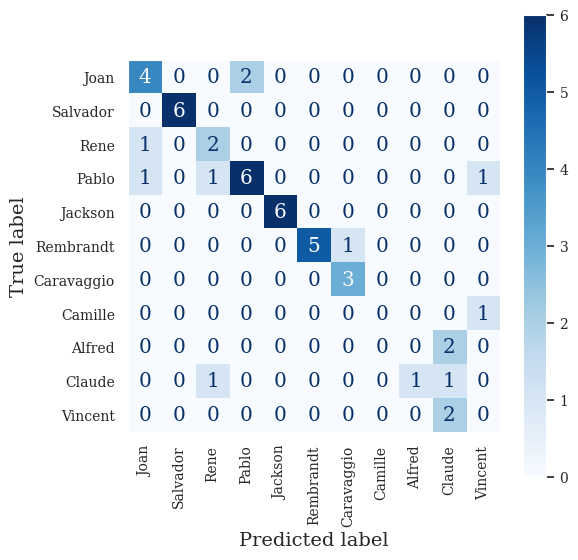

In [33]:
from sklearn.metrics import ConfusionMatrixDisplay

# plot confusion matrix as heatmap
class_names = [inv_genre[i] for i in range(len(genre_to_label))]
fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap='Blues')
plt.grid(False)
# rotate x labels
plt.xticks(rotation=90)
plt.show()

In [34]:
ds = val_ul  # change for each quadrant: val_ul, val_ur, val_ll, val_lr
loader = DataLoader(
    ds,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

all_preds = []
all_labels = []

model_q = model_deep.to(device)
model_q.eval()

with torch.no_grad():
    for imgs, labels in loader:
        imgs   = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        logits = model_q(imgs)
        _, preds = logits.max(1)

        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

y_true = np.concatenate(all_labels)
y_pred = np.concatenate(all_preds)


painter_to_genre = {
    "Joan": "Surrealismo",
    "Salvador": "Surrealismo",
    "Rene": "Surrealismo",
    "Pablo": "Cubismo",
    "Jackson": "Expresionismo abstracto",
    "Rembrandt": "Barroco",
    "Caravaggio": "Barroco",
    "Camille": "Impresionismo",
    "Alfred": "Impresionismo",
    "Claude": "Impresionismo",
    "Vincent": "Impresionismo",  
}

genre_to_label = {
    "Surrealismo": 0,
    "Cubismo": 1,
    "Expresionismo abstracto": 2,
    "Barroco": 3,
    "Impresionismo": 4,
}

# Map painter labels to genre labels
painter_to_genre_label = [genre_to_label[painter_to_genre[p]] for p in painter_to_genre.keys()]
y_pred_genre = np.array([painter_to_genre_label[p] for p in y_pred])
y_true_genre = np.array([painter_to_genre_label[p] for p in y_true])

# import confusion_matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true_genre, y_pred_genre, labels=np.arange(len(genre_to_label)))
# TPR_c = CM[c,c] / sum_j CM[c,j]
denom = cm.sum(axis=1).clip(min=1)  # avoid division by zero
tpr = cm.diagonal() / denom

print("Confusion matrix:\n", cm)
print("TPR (Sensitivity/Recall per class):", tpr)

# Additional metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

acc = accuracy_score(y_true_genre, y_pred_genre)
precision = precision_score(y_true_genre, y_pred_genre, average=None)
recall = recall_score(y_true_genre, y_pred_genre, average=None)  # same as tpr
f1 = f1_score(y_true_genre, y_pred_genre, average=None)
f1_macro = f1_score(y_true_genre, y_pred_genre, average='macro')

# Specificity per class
num_classes = len(genre_to_label)
specificity = []
for c in range(num_classes):
    tp = cm[c, c]
    fn = cm[c, :].sum() - tp
    fp = cm[:, c].sum() - tp
    tn = cm.sum() - (tp + fn + fp)
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    specificity.append(spec)
specificity = np.array(specificity)

print("Accuracy:", acc)
print("Precision per class:", precision)
print("Recall (Sensitivity) per class:", recall)
print("Specificity per class:", specificity)
print("F1 per class:", f1)
print("F1 Macro:", f1_macro)


Confusion matrix:
 [[13  2  0  0  0]
 [ 2  6  0  0  1]
 [ 0  0  6  0  0]
 [ 0  0  0  9  0]
 [ 1  0  0  0  7]]
TPR (Sensitivity/Recall per class): [0.86666667 0.66666667 1.         1.         0.875     ]
Accuracy: 0.8723404255319149
Precision per class: [0.8125 0.75   1.     1.     0.875 ]
Recall (Sensitivity) per class: [0.86666667 0.66666667 1.         1.         0.875     ]
Specificity per class: [0.90625    0.94736842 1.         1.         0.97435897]
F1 per class: [0.83870968 0.70588235 1.         1.         0.875     ]
F1 Macro: 0.8839184060721064


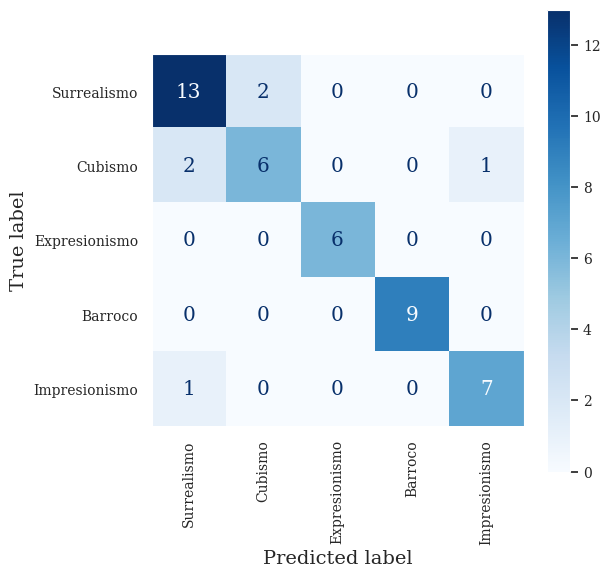

In [35]:

from sklearn.metrics import ConfusionMatrixDisplay

# plot confusion matrix as heatmap
class_names = ["Surrealismo", "Cubismo", "Expresionismo", "Barroco", "Impresionismo"]
fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap='Blues')
plt.grid(False)
# rotate x labels
plt.xticks(rotation=90)
plt.show()

